In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
from pathlib import Path
BASE_DIR = Path.cwd().parent
MASTER = BASE_DIR / "data" / "master"
df_original = pd.read_csv(MASTER / "processed_abuja_rentals.csv")

df = df_original.copy()

In [8]:
print(df.shape)
print(df.dtypes.head(10))
df.head()

(4300, 34)
Bedrooms                               int64
Price (Per Annum)                    float64
Log_Price                            float64
Property Category_Bungalow             int64
Property Category_Duplex               int64
Property Category_House                int64
District_Tier_Tier 2 - Mid-Market      int64
District_Tier_Tier 3 - Affordable      int64
District_Asokoro                       int64
District_Durumi                        int64
dtype: object


,Bedrooms,Price (Per Annum),Log_Price,Property Category_Bungalow,Property Category_Duplex,Property Category_House,District_Tier_Tier 2 - Mid-Market,District_Tier_Tier 3 - Affordable,District_Asokoro,District_Durumi,...,District_Kaura,District_Kubwa,District_Life Camp,District_Lokogoma,District_Lugbe,District_Mabushi,District_Maitama,District_Utako,District_Wuse,District_Wuye
0,1,600000.0,13.304687,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
1,1,1500000.0,14.220976,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
2,1,1200000.0,13.997833,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,1,1200000.0,13.997833,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
4,2,1140000.0,13.946540,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [11]:
# Define Features (X) and Target (y)
# Define target
y = df['Log_Price']

# Define features
X = df.drop(columns=['Log_Price', 'Price (Per Annum)'])

In [15]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on the test set
lr_predictions = lr_model.predict(X_test)

# Evaluate the model
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print(f"MAE:  {lr_mae:.4f}")
print(f"RMSE: {lr_rmse:.4f}")
print(f"R²:   {lr_r2:.4f}")

MAE:  0.3799
RMSE: 0.5333
R²:   0.7174


In [16]:
#Random Forest Model
# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

# Evaluate the model
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print(f"MAE:  {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R²:   {rf_r2:.4f}")


MAE:  0.3475
RMSE: 0.4901
R²:   0.7613


In [17]:
#Model Comparison
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R² Score': [lr_r2, rf_r2]
})

display(results_df)

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.379854,0.533303,0.717426
1,Random Forest,0.347529,0.490143,0.761313


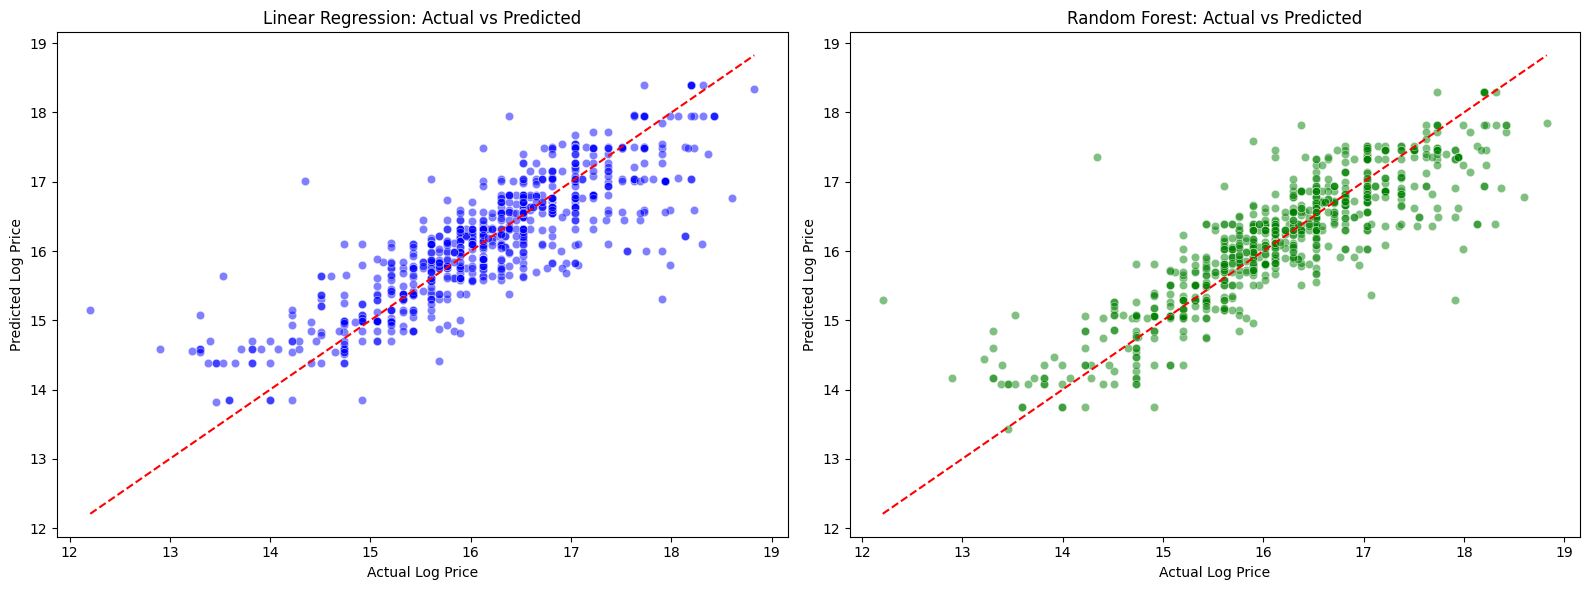

In [ ]:
#Plot Actual vs Predicted for both models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

min_val = min(y_test.min(), lr_predictions.min(), rf_predictions.min())
max_val = max(y_test.max(), lr_predictions.max(), rf_predictions.max())

# Plot Linear Regression
sns.scatterplot(x=y_test, y=lr_predictions, alpha=0.5, ax=axes[0], color='blue')
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--') # Reference line
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Actual Log Price')
axes[0].set_ylabel('Predicted Log Price')

# Plot Random Forest
sns.scatterplot(x=y_test, y=rf_predictions, alpha=0.5, ax=axes[1], color='green')
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--') # Reference line
axes[1].set_title('Random Forest: Actual vs Predicted')
axes[1].set_xlabel('Actual Log Price')
axes[1].set_ylabel('Predicted Log Price')

plt.tight_layout()
plt.show()

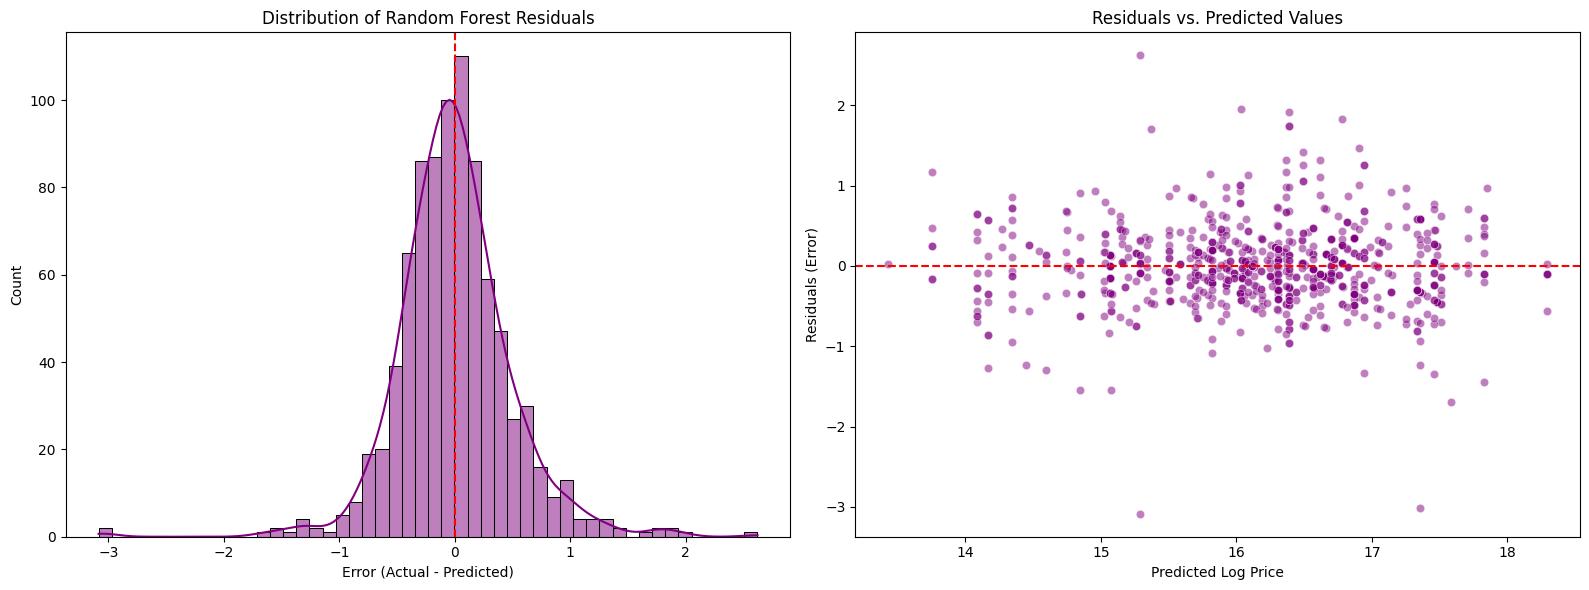

In [19]:
#Analyze errors of the best performing model
rf_residuals = y_test - rf_predictions

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residual Distribution Plot
sns.histplot(rf_residuals, bins=50, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Distribution of Random Forest Residuals')
axes[0].set_xlabel('Error (Actual - Predicted)')
axes[0].axvline(x=0, color='red', linestyle='--')

# Residuals vs Predicted (Homoscedasticity check)
sns.scatterplot(x=rf_predictions, y=rf_residuals, alpha=0.5, ax=axes[1], color='purple')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residuals vs. Predicted Values')
axes[1].set_xlabel('Predicted Log Price')
axes[1].set_ylabel('Residuals (Error)')

plt.tight_layout()
plt.show()

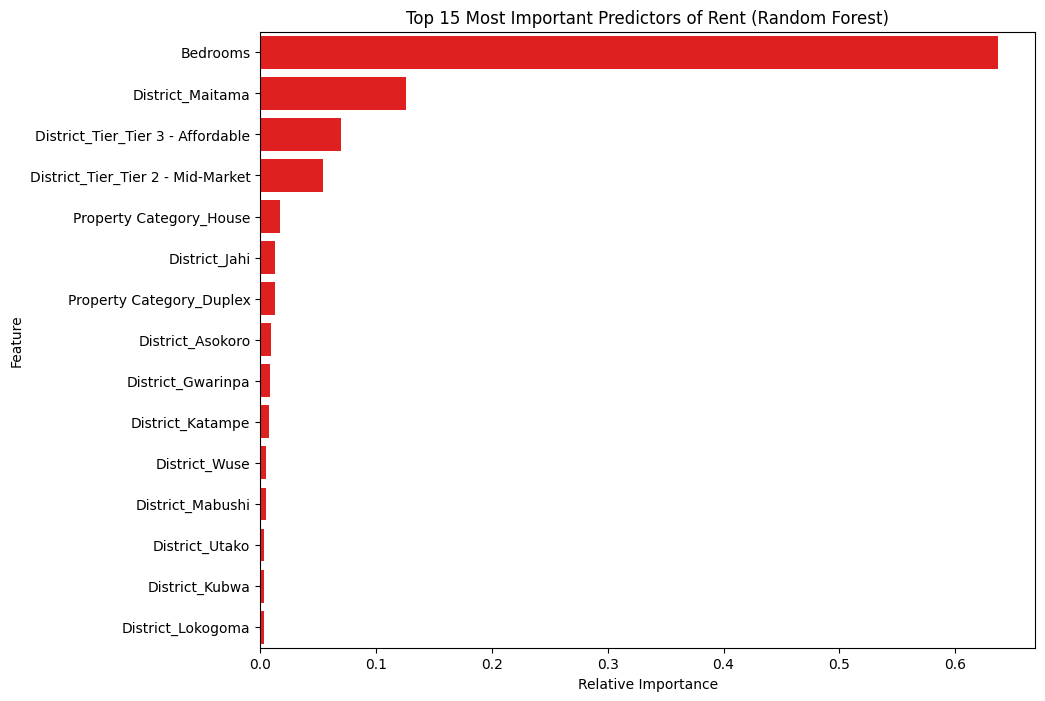

In [21]:
#Explain feature importance logic.
importance = rf_model.feature_importances_

feature_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_df.head(15), x='Importance', y='Feature', color='red')
plt.title('Top 15 Most Important Predictors of Rent (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
# Save the model and feature columns
import joblib
model_filename = 'abuja_rent_model.pkl'
joblib.dump(rf_model, model_filename)
columns_filename = 'feature_columns.pkl'
joblib.dump(list(X.columns), columns_filename)

['feature_columns.pkl']